In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
import os
import pandas as pd  # 添加pandas导入

# 检查CUDA可用性并设置设备
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

使用设备: cuda


In [2]:
def load_baseline_solution(filename='kdv_baseline_solution.npz'):
    """从文件加载基线解"""
    data = np.load(filename)
    print(f"Baseline solution loaded from {filename}")
    return data['usol'], data['x'], data['t_eval']

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.Tanh()]
        for _ in range(5):  # 改为5次循环，总共6层隐藏层
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, out_dim))
        self.net = nn.Sequential(*layers)
        
    
    def forward(self, x):
        return self.net(x)

class KdV_PINN(nn.Module):
    def __init__(self, T):
        super().__init__()
        self.T = T
        self.model = MLP(2, 50, 1)  # 改为50个神经元每层
    
    def forward(self, x, t):
        XT = torch.cat([x, t], dim=1)
        return self.model(XT)
    
    def loss_pde(self, x, t):
        x = x.clone().requires_grad_(True)
        t = t.clone().requires_grad_(True)
        u = self.forward(x, t)
        u_t   = torch.autograd.grad(u, t, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x   = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx  = torch.autograd.grad(u_x, x, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        u_xxx = torch.autograd.grad(u_xx, x, grad_outputs=torch.ones_like(u_xx), create_graph=True)[0]
        res = u_t + 6 * u * u_x + u_xxx
        return torch.mean(res**2)
    
    def loss_ic(self, x):
        u_pred = self.forward(x, torch.zeros_like(x))
        u_true = torch.sin(x)
        return torch.mean((u_pred - u_true)**2)
    
    def loss_bc(self, t):
        x0 = torch.zeros_like(t)
        x1 = torch.ones_like(t) * (2 * np.pi)
        u0 = self.forward(x0, t)
        u1 = self.forward(x1, t)
        return torch.mean((u0 - u1)**2)
    
    def train_model(self, epochs, lr, N_pde, N_ic, N_bc, device):
        self.to(device)
        optimizer = optim.Adam(self.parameters(), lr=lr)
        w_pde, w_ic, w_bc = 1.0, 100.0, 100.0
        history = {'pde': [], 'ic': [], 'bc': [], 'total': []}
        

        start_time = time.time()
        
        for ep in range(1, epochs+1):
            x_p = torch.rand(N_pde, 1, device=device) * 2 * np.pi
            t_p = torch.rand(N_pde, 1, device=device) * self.T
            x_i = torch.rand(N_ic, 1, device=device) * 2 * np.pi
            t_b = torch.rand(N_bc, 1, device=device) * self.T
            
            l_pde = self.loss_pde(x_p, t_p)
            l_ic  = self.loss_ic(x_i)
            l_bc  = self.loss_bc(t_b)
            loss  = w_pde * l_pde + w_ic * l_ic + w_bc * l_bc
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            history['pde'].append(l_pde.item())
            history['ic'].append(l_ic.item())
            history['bc'].append(l_bc.item())
            history['total'].append(loss.item())
            
            if ep == 1 or ep % 1000 == 0:
                print(f"Epoch {ep:4d} | Loss {loss:.2e}")
        
        training_time = time.time() - start_time
        print(f"PINN training completed in {training_time:.2f} seconds")
        
        return history

In [4]:
# Load pre-computed baseline solution
baseline_file = 'kdv_baseline_solution.npz'
usol, x, t_eval = load_baseline_solution(baseline_file)

# Extract domain parameters from loaded data
Lx = 2 * np.pi
T = 0.6
Nx = len(x)
t_points = len(t_eval)

# Train PINN
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  Device: {device}")

pinn = KdV_PINN(T)
history = pinn.train_model(epochs=10000, lr=1e-3, N_pde=3000, N_ic=500, N_bc=500, device=device)

# Evaluate PINN on full mesh
print("\nEvaluating PINN on full spatial-temporal grid...")
T2D, X2D = np.meshgrid(t_eval, x, indexing='ij')
X_flat = torch.tensor(X2D.reshape(-1,1), dtype=torch.float32, device=device)
T_flat = torch.tensor(T2D.reshape(-1,1), dtype=torch.float32, device=device)

with torch.no_grad():
    u_pinn = pinn(X_flat, T_flat).cpu().numpy().reshape(t_points, Nx)

# Compute error metrics
err = u_pinn - usol
emax = np.max(np.abs(err))
emean = np.mean(np.abs(err))
erms = np.sqrt(np.mean(err**2))

print(f"\nError Analysis:")
print(f"  Maximum absolute error: {emax:.2e}")
print(f"  Mean absolute error:    {emean:.2e}")
print(f"  RMS error:              {erms:.2e}")

Baseline solution loaded from kdv_baseline_solution.npz
  Device: cuda


f:\Anaconda\envs\fxxkingpaperenv\Lib\site-packages\torch\autograd\graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch    1 | Loss 4.89e+01
Epoch 1000 | Loss 2.08e+00
Epoch 2000 | Loss 1.71e+00
Epoch 3000 | Loss 1.01e+00
Epoch 4000 | Loss 7.87e-01
Epoch 5000 | Loss 7.07e-01
Epoch 6000 | Loss 4.92e-01
Epoch 7000 | Loss 3.91e-01
Epoch 8000 | Loss 2.71e-01
Epoch 9000 | Loss 2.53e-01
Epoch 10000 | Loss 1.27e-01
PINN training completed in 269.33 seconds

Evaluating PINN on full spatial-temporal grid...

Error Analysis:
  Maximum absolute error: 6.09e-01
  Mean absolute error:    1.31e-01
  RMS error:              1.71e-01


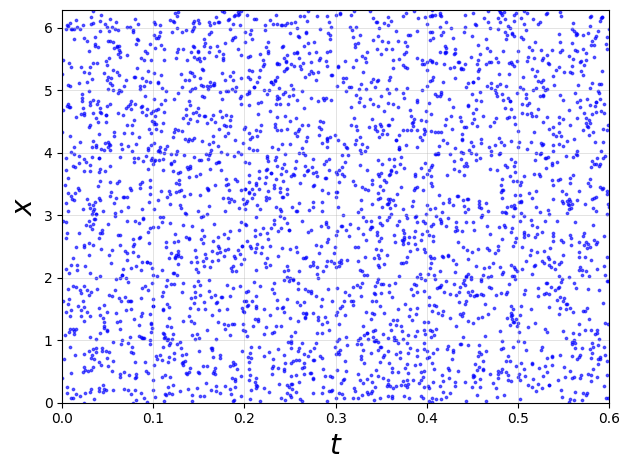

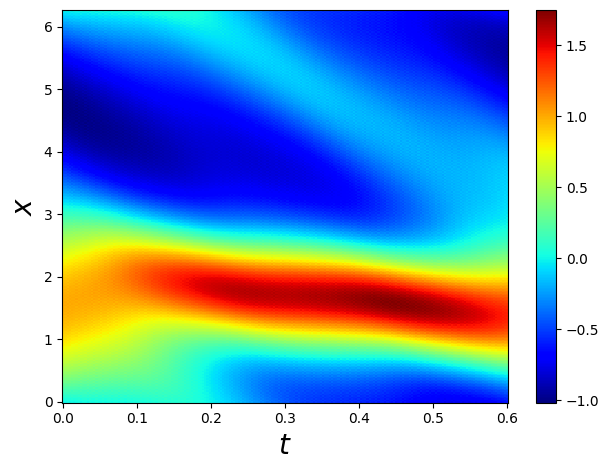

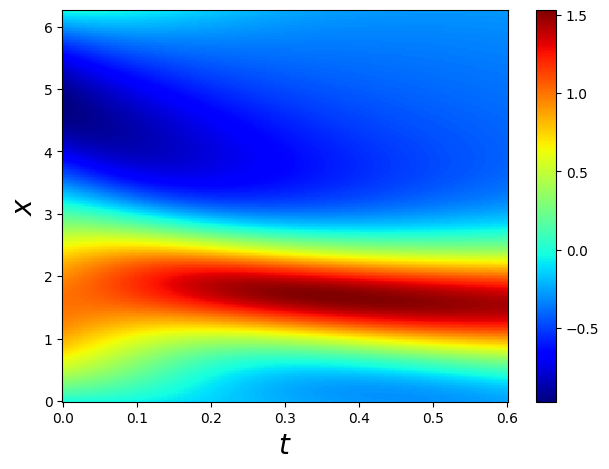

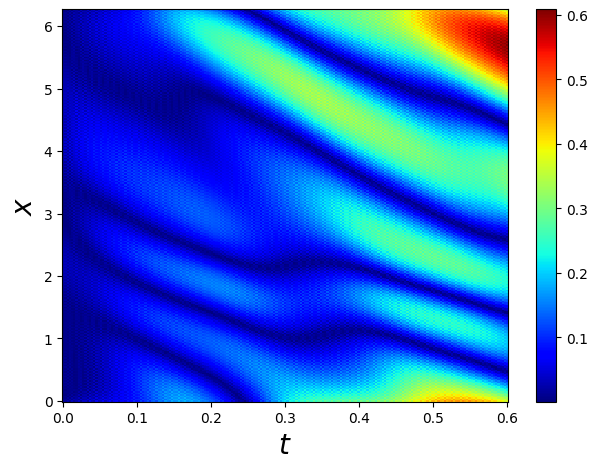

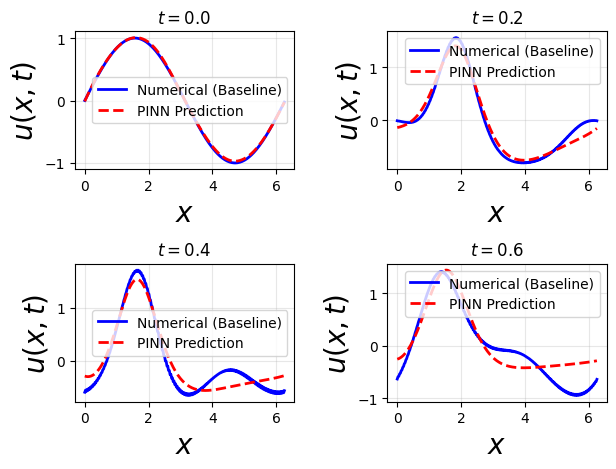

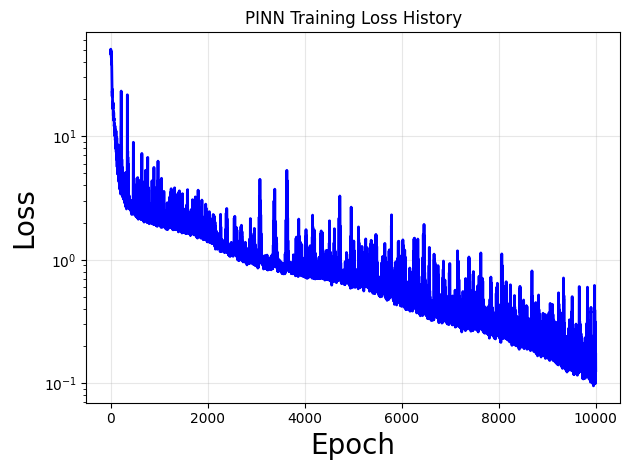


=== 保存PINN训练Loss历史数据 ===
PINN Loss历史数据已保存到: kdv_pinn_loss_history.csv
PINN Loss历史数据也已保存为: kdv_pinn_loss_history.npz

=== PINN Analysis Complete ===
Final maximum error: 6.09e-01
Total training epochs: 10000

=== Saving Time Slice Data ===
时间切片 t=0.0 已保存到: u_pinn_slice_t_0.0.csv
时间切片 t=0.2 已保存到: u_pinn_slice_t_0.2.csv
时间切片 t=0.4 已保存到: u_pinn_slice_t_0.4.csv
时间切片 t=0.6 已保存到: u_pinn_slice_t_0.6.csv
所有时间切片数据已保存完成！


In [ ]:
# ----------------------------------------
# 精简可视化（按要求定制）
# ----------------------------------------

# Generate PDE sampling points for visualization
np.random.seed(42)  # For reproducible sampling points
N_vis_pde = 3000  # Only PDE points

# PDE collocation points
x_pde_vis = np.random.uniform(0, 2*np.pi, N_vis_pde)
t_pde_vis = np.random.uniform(0, T, N_vis_pde)

# 1) 采样点分布图（t为横坐标，x为纵坐标，只显示PDE Points）
fig_sample, ax = plt.subplots(1, 1)
ax.scatter(t_pde_vis, x_pde_vis, c='blue', s=3, alpha=0.6)
ax.set_xlabel('$t$', fontsize=20)
ax.set_ylabel('$x$', fontsize=20)
ax.grid(True, alpha=0.5, linestyle='-', linewidth=0.5)
ax.set_xlim([0, T])
ax.set_ylim([0, 2*np.pi])
plt.tight_layout()
plt.show()

# 2) 热图对比（三张图单独输出，t为横坐标，x为纵坐标，使用jet色彩映射）

# 创建网格坐标
T_grid, X_grid = np.meshgrid(t_eval, x)

# 第一张图：数值解
fig1, ax1 = plt.subplots()
im1 = ax1.pcolormesh(T_grid, X_grid, usol.T, cmap='jet', shading='auto')
ax1.set_xlabel('$t$', fontsize=20)
ax1.set_ylabel('$x$', fontsize=20)
cbar1 = fig1.colorbar(im1, ax=ax1)
plt.tight_layout()
plt.show()

# 第二张图：PINN解
fig2, ax2 = plt.subplots()
im2 = ax2.pcolormesh(T_grid, X_grid, u_pinn.T, cmap='jet', shading='auto')
ax2.set_xlabel('$t$', fontsize=20)
ax2.set_ylabel('$x$', fontsize=20)
cbar2 = fig2.colorbar(im2, ax=ax2)
plt.tight_layout()
plt.show()

# 第三张图：绝对误差
fig3, ax3 = plt.subplots()
im3 = ax3.pcolormesh(T_grid, X_grid, np.abs(err).T, cmap='jet', shading='auto')
ax3.set_xlabel('$t$', fontsize=20)
ax3.set_ylabel('$x$', fontsize=20)
cbar3 = fig3.colorbar(im3, ax=ax3)
plt.tight_layout()
plt.show()

# 3) 不同时间切片的对比（使用plt.plot）
fig_cs, axes_cs = plt.subplots(2, 2)  # 移除figsize，使用默认大小
times = [0.0, 0.2, 0.4, 0.6]

for ax, tval in zip(axes_cs.flatten(), times):
    idx = np.searchsorted(t_eval, tval)
    ax.plot(x, usol[idx], 'b-', linewidth=2, label='Numerical (Baseline)')
    ax.plot(x, u_pinn[idx], 'r--', linewidth=2, label='PINN Prediction')
    ax.set_title(f'$t = {tval:.1f}$')
    ax.set_xlabel('$x$', fontsize=20)
    ax.set_ylabel('$u(x,t)$', fontsize=20)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

# 4) Loss History（使用plt.plot）- 修改这部分
fig_loss, ax_loss = plt.subplots()
ax_loss.plot(history['total'], 'b-', linewidth=2)
ax_loss.set_yscale('log')
ax_loss.set_xlabel('Epoch', fontsize=20)
ax_loss.set_ylabel('Loss', fontsize=20)
ax_loss.set_title('PINN Training Loss History')
ax_loss.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 保存Loss历史数据
print(f"\n=== 保存PINN训练Loss历史数据 ===")
import pandas as pd

# 准备Loss数据
loss_data = []
for epoch in range(len(history['total'])):
    loss_data.append({
        'epoch': epoch,
        'total_loss': history['total'][epoch],
        'pde_loss': history['pde'][epoch],
        'ic_loss': history['ic'][epoch],
        'bc_loss': history['bc'][epoch]
    })

# 保存为CSV文件
# loss_df = pd.DataFrame(loss_data)
# loss_filename = 'kdv_pinn_loss_history.csv'
# loss_df.to_csv(loss_filename, index=False)
# print(f"PINN Loss历史数据已保存到: {loss_filename}")

# 同时保存为numpy格式
np.savez('kdv_pinn_loss_history.npz',
         epochs=np.arange(len(history['total'])),
         total_loss=np.array(history['total']),
         pde_loss=np.array(history['pde']),
         ic_loss=np.array(history['ic']),
         bc_loss=np.array(history['bc']))
print("PINN Loss历史数据也已保存为: kdv_pinn_loss_history.npz")

print(f"\n=== PINN Analysis Complete ===")
print(f"Final maximum error: {emax:.2e}")
print(f"Total training epochs: {len(history['total'])}")

# 5) 保存时间切片数据为CSV文件
print(f"\n=== Saving Time Slice Data ===")
key_times = [0.0, 0.2, 0.4, 0.6]  # 与可视化中使用的时间点保持一致

for t_target in key_times:
    if t_target <= t_eval[-1]:
        t_idx = np.searchsorted(t_eval, t_target)
        
        slice_data = pd.DataFrame({
            'x_index': range(len(x)),
            'x_value': x,
            'u_pinn': u_pinn[t_idx, :],
            'u_numerical': usol[t_idx, :],
            'error': u_pinn[t_idx, :] - usol[t_idx, :],
            'notes': ''  # 空列用于添加编辑备注
        })
        
        # filename = f'u_pinn_slice_t_{t_target:.1f}.csv'
        # slice_data.to_csv(filename, index=False)
        # print(f"时间切片 t={t_target:.1f} 已保存到: {filename}")

print(f"所有时间切片数据已保存完成！")


=== 计算PINN系统能量 ===
计算数值解（Baseline）的能量...
计算PINN解的能量...


D:\TempFiles\ipykernel_32008\1079129574.py:20: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  total_energy = np.trapz(E, dx=dx, axis=1)  # 沿空间维度积分


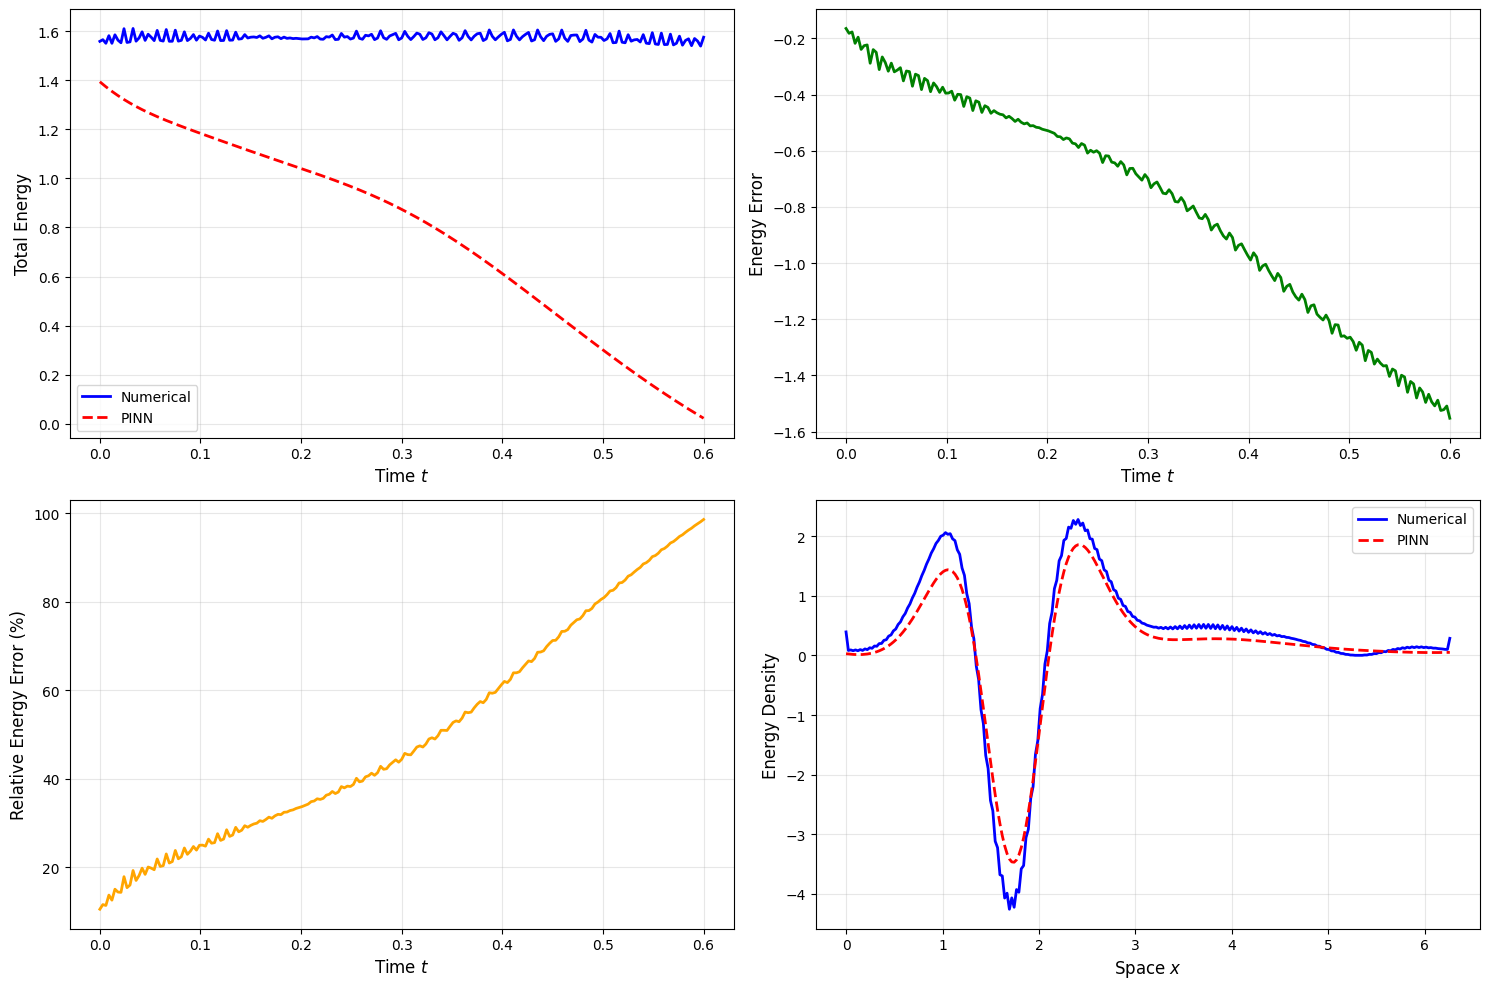


能量分析数据已保存到: kdv_pinn_energy_analysis.csv
能量分析数据也已保存为: kdv_pinn_energy_analysis.npz


<Figure size 640x480 with 0 Axes>

能量分析完成！


In [ ]:
# 计算PINN系统的能量
print(f"\n=== 计算PINN系统能量 ===")

def compute_energy_density(u, x):
    """计算能量密度 E = 0.5 * (u_x)^2 - u^3"""
    # 计算空间导数 u_x
    dx = x[1] - x[0]  # 假设均匀网格
    u_x = np.gradient(u, dx, axis=1)  # 沿空间维度计算梯度
    
    # 计算能量密度
    E = 0.5 * u_x**2 - u**3
    return E, u_x

def compute_total_energy(u, x):
    """计算总能量（在空间域上积分）"""
    E, u_x = compute_energy_density(u, x)
    
    # 在空间域上积分（使用梯形法则）
    dx = x[1] - x[0]
    total_energy = np.trapz(E, dx=dx, axis=1)  # 沿空间维度积分
    
    return total_energy, E, u_x

# 1. 计算数值解的能量
print("计算数值解（Baseline）的能量...")
energy_numerical, E_numerical, ux_numerical = compute_total_energy(usol, x)

# 2. 计算PINN解的能量
print("计算PINN解的能量...")
energy_pinn, E_pinn, ux_pinn = compute_total_energy(u_pinn, x)

# 3. 计算能量误差
energy_error = energy_pinn - energy_numerical
relative_energy_error = np.abs(energy_error) / np.abs(energy_numerical) * 100

# 4. 可视化能量随时间的变化
fig_energy, axes_energy = plt.subplots(2, 2, figsize=(15, 10))

# 4.1 总能量随时间变化
ax1 = axes_energy[0, 0]
ax1.plot(t_eval, energy_numerical, 'b-', linewidth=2, label='Numerical')
ax1.plot(t_eval, energy_pinn, 'r--', linewidth=2, label='PINN')
ax1.set_xlabel('Time $t$', fontsize=12)
ax1.set_ylabel('Total Energy', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.legend()

# 4.2 能量误差
ax2 = axes_energy[0, 1]
ax2.plot(t_eval, energy_error, 'g-', linewidth=2)
ax2.set_xlabel('Time $t$', fontsize=12)
ax2.set_ylabel('Energy Error', fontsize=12)
ax2.grid(True, alpha=0.3)

# 4.3 相对能量误差
ax3 = axes_energy[1, 0]
ax3.plot(t_eval, relative_energy_error, 'orange', linewidth=2)
ax3.set_xlabel('Time $t$', fontsize=12)
ax3.set_ylabel('Relative Energy Error (%)', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4.4 能量密度在某个时间点的空间分布
t_idx = len(t_eval) // 2  # 中间时间点
ax4 = axes_energy[1, 1]
ax4.plot(x, E_numerical[t_idx], 'b-', linewidth=2, label='Numerical')
ax4.plot(x, E_pinn[t_idx], 'r--', linewidth=2, label='PINN')
ax4.set_xlabel('Space $x$', fontsize=12)
ax4.set_ylabel('Energy Density', fontsize=12)
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# 7. 保存能量数据
energy_data = pd.DataFrame({
    'time': t_eval,
    'energy_numerical': energy_numerical,
    'energy_pinn': energy_pinn,
    'energy_error': energy_error,
    'relative_energy_error': relative_energy_error
})

# energy_filename = 'kdv_pinn_energy_analysis.csv'
# energy_data.to_csv(energy_filename, index=False)
# print(f"\n能量分析数据已保存到: {energy_filename}")

# 同时保存为numpy格式
np.savez('kdv_pinn_energy_analysis.npz',
         time=t_eval,
         energy_numerical=energy_numerical,
         energy_pinn=energy_pinn,
         energy_error=energy_error,
         relative_energy_error=relative_energy_error,
         E_numerical=E_numerical,
         E_pinn=E_pinn)
# print("能量分析数据也已保存为: kdv_pinn_energy_analysis.npz")

plt.tight_layout()
plt.show()

print("能量分析完成！")